In [139]:
# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.tensorboard import SummaryWriter

sns.set(font_scale=1.4)
sns.set_style("white")
plt.rc("font", size=14)

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

print(f"Device: {device}")

# ImageNet stats for EfficientNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training config
IMG_SIZE = 256
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 1000
PATIENCE = 30

print("Configuration")
print(f"  Image size: {IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Patience: {PATIENCE}")
print(f"  Max epochs: {EPOCHS}")

# Paths – adjust to your structure
PATH = "/kaggle/input/merged-dataset/"
TRAIN_IMG_DIR = "/kaggle/input/merged-dataset" #+ "train_data_cleaned/images"   # contains img_0001.png, ...
#TRAIN_MASK_DIR = PATH + "train_data_cleaned/masks"   # contains mask_0001.png, ...
TEST_IMG_DIR = "/kaggle/input/final-test2"     # contains img_XXXX.png
TRAIN_LABELS_CSV = PATH + "train_label.csv" # mapping image name to class label
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

import tifffile as tiff
from PIL import Image

Device: cuda
Configuration
  Image size: 256
  Batch size: 64
  Learning rate: 0.001
  Patience: 30
  Max epochs: 1000


In [78]:
# 2. Utility functions
# ============================================================

def mask_to_bbox(mask: np.ndarray):
    """
    From a single channel mask compute tight bounding box.

    Args:
        mask: 2D numpy array, non zero pixels are foreground

    Returns:
        (x1, y1, x2, y2) in absolute pixel coordinates
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        # fall back to full image if mask empty
        h, w = mask.shape
        return 0, 0, w - 1, h - 1
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return x1, y1, x2, y2


def spearman_rho(predictions, targets):
    """
    Spearman rank correlation between two vectors.

    Predictions and targets can be numpy arrays or tensors.
    Computed over flattened coordinates.
    """
    if isinstance(predictions, np.ndarray):
        predictions = torch.from_numpy(predictions)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)

    predictions = predictions.float().flatten()
    targets = targets.float().flatten()

    def rank(x):
        sorted_indices = torch.argsort(x)
        ranks = torch.argsort(sorted_indices) + 1
        return ranks.float()

    r_pred = rank(predictions)
    r_tgt = rank(targets)

    diff_pred = r_pred - r_pred.mean()
    diff_tgt = r_tgt - r_tgt.mean()

    cov = (diff_pred * diff_tgt).mean()
    std_pred = torch.sqrt((diff_pred ** 2).mean())
    std_tgt = torch.sqrt((diff_tgt ** 2).mean())

    return cov / (std_pred * std_tgt + 1e-8)

In [79]:
# 3. Data loading – localisation from masks
# ============================================================

def load_localisation_data(img_dir, img_dim):
    """
    Load images and corresponding masks, compute bounding boxes.

    Assumes:
      - image files named like img_0001.png
      - mask files named like mask_0001.png
    """
#CHANGED
    image_files = sorted(
        [f for f in os.listdir(img_dir) if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))]
    )

    images = []
    boxes = []

    for fname in image_files:
        img_path = os.path.join(img_dir, fname)
                # Read image with PIL (supports TIFF)
        try:
            img = Image.open(img_path)

            # If multi-page TIFF, take first page
            if getattr(img, "n_frames", 1) > 1:
                img.seek(0)

            img = np.array(img)

        except Exception as e:
            print(f"Skipping {fname}, cannot read TIFF: {e}")
            continue


        # Ensure 4 channels
        if img.ndim == 2:  # grayscale only → replicate + dummy mask
            img = np.stack([img]*3 + [np.zeros_like(img)], axis=-1)
            print("ndim  = 2!!!")
        elif img.shape[-1] == 3:  # RGB only → append dummy mask
            mask_channel = np.zeros_like(img[:, :, 0])
            img = np.dstack([img, mask_channel])
            print("only RGB!!!")
        elif img.shape[-1] == 4:  # RGBA → keep all 4 channels
            img = img[:, :, :4]
        else:
            # unexpected channels → pad/crop to 4
            print("channels fucked up")
            h, w = img.shape[:2]
            tmp = np.zeros((h, w, 4), dtype=img.dtype)
            tmp[:, :, :img.shape[-1]] = img
            img = tmp
            
        # img = tiff.imread(img_path)
        # if img is None:
        #     continue
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_dim, img_dim))

        # build mask name from image name
        # img_0001.png -> mask_0001.png
        # base = fname.replace("img_", "")
        # mask_name = f"mask_{base}"
        # mask_path = os.path.join(mask_dir, mask_name)
        # mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        # if mask is None:
        #     raise FileNotFoundError(f"Mask not found for {fname}: {mask_path}")
        # mask = cv2.resize(mask, (img_dim, img_dim), interpolation=cv2.INTER_NEAREST)

        # x1, y1, x2, y2 = mask_to_bbox(mask)
        # h, w = mask.shape
        bbox =  [0.0, 0.0, 0.0, 0.0]

        images.append(img)
        boxes.append(bbox)

    images = np.array(images)
    boxes = np.array(boxes, dtype=np.float32)

    print(f"Localisation data loaded: {len(images)} images")
    print(f"Image shape: {images[0].shape}")
    return images, boxes


X_loc, y_boxes = load_localisation_data(TRAIN_IMG_DIR, IMG_SIZE)

Localisation data loaded: 1239 images
Image shape: (256, 256, 4)


In [80]:
import os

print(os.listdir("/kaggle/input"))


['final-test', 'merged-dataset']


In [81]:
import pandas as pd
import os

# Path to your CSV and image folder
csv_path = TRAIN_LABELS_CSV
img_dir = TRAIN_IMG_DIR

# Read CSV
df = pd.read_csv(csv_path)

# Rewrite filenames: change .png to .tif
def fix_filename(fname):
    base, ext = os.path.splitext(fname)
    return base + ".tif"  # or ".tiff" if your files use that

df['sample_index'] = df['sample_index'].apply(fix_filename)

# Optional: check first few rows
print(df.head())

# Save back to CSV (overwrite or new file)
fixed_csv_path = "train_labels_fixed.csv"
df.to_csv(fixed_csv_path, index=False)

print(f"Fixed CSV saved to {fixed_csv_path}")


     sample_index            label
0  image_0000.tif  Triple negative
1  image_0001.tif        Luminal A
2  image_0002.tif        Luminal A
3  image_0003.tif        Luminal B
4  image_0004.tif          HER2(+)
Fixed CSV saved to train_labels_fixed.csv


In [82]:
from sklearn.preprocessing import LabelEncoder

# y_cls are strings like 'Triple negative', 'Luminal A', etc.
label_encoder = LabelEncoder()
y_cls_int = label_encoder.fit_transform(y_cls)   # shape (N,)

# numeric label -> name mapping
num_to_labels = {i: lab for i, lab in enumerate(label_encoder.classes_)}

print("Classes:", num_to_labels)

Classes: {0: 'HER2(+)', 1: 'Luminal A', 2: 'Luminal B', 3: 'Triple negative'}


In [83]:
# 4. Data loading – classification from CSV
# ============================================================

from sklearn.preprocessing import LabelEncoder

def load_classification_data(img_dir, labels_csv, img_dim,
                             img_col='sample_index',
                             label_col='label'):
    """
    Load images and string labels from a CSV.

    Returns:
        X: np.array of images (N, H, W, C)
        y: np.array of string labels (N,)
    """
    df = pd.read_csv(labels_csv)

    images = []
    labels = []

    for _, row in df.iterrows():
        fname = str(row[img_col])
        label = str(row[label_col])    # keep as string
        # --- Adjust filename inside the loop ---
        base, ext = os.path.splitext(fname)
        # change to actual extension of your images
        fname_fixed = base + ".tiff"  
    
        img_path = os.path.join(img_dir, fname_fixed)
        try:
            img = Image.open(img_path)

            # If multi-page TIFF, take the first page
            if getattr(img, "n_frames", 1) > 1:
                img.seek(0)

            img = np.array(img)

        except Exception as e:
            print(f"Skipping {fname}, cannot read TIFF: {e}")
            continue

        # Ensure 4 channels (RGB + mask)
        if img.ndim == 2:  # grayscale → replicate + dummy mask
            img = np.stack([img]*3 + [np.zeros_like(img)], axis=-1)
            print("ndim  = 2!!!")

        elif img.shape[-1] == 3:  # RGB only → append dummy mask
            mask_channel = np.zeros_like(img[:, :, 0])
            img = np.dstack([img, mask_channel])
            print("ndim  = 3!!!")

        elif img.shape[-1] == 4:  # RGBA → keep first 4 channels
            img = img[:, :, :4]
        else:
            # Unexpected channel number → pad/crop to 4
            print("ndim  = 5!!!")

            h, w = img.shape[:2]
            tmp = np.zeros((h, w, 4), dtype=img.dtype)
            tmp[:, :, :img.shape[-1]] = img
            img = tmp

        # center crop to square
        dim = min(img.shape[:-1])
        img = img[(img.shape[0]-dim)//2:(img.shape[0]+dim)//2,
                  (img.shape[1]-dim)//2:(img.shape[1]+dim)//2]
        img = cv2.resize(img, (img_dim, img_dim), interpolation=cv2.INTER_AREA)
        #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)


# Load classification data as images + string labels
X_cls, y_cls = load_classification_data(TRAIN_IMG_DIR, TRAIN_LABELS_CSV, IMG_SIZE)

# Encode string labels to integers
label_encoder = LabelEncoder()
y_cls_encoded = label_encoder.fit_transform(y_cls)

# number of classes and mapping int -> name
num_classes = len(label_encoder.classes_)
class_names = list(label_encoder.classes_)  # e.g. ["HER2(+)", "Luminal A", ...]
print("Classes:", class_names)

Classes: ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']


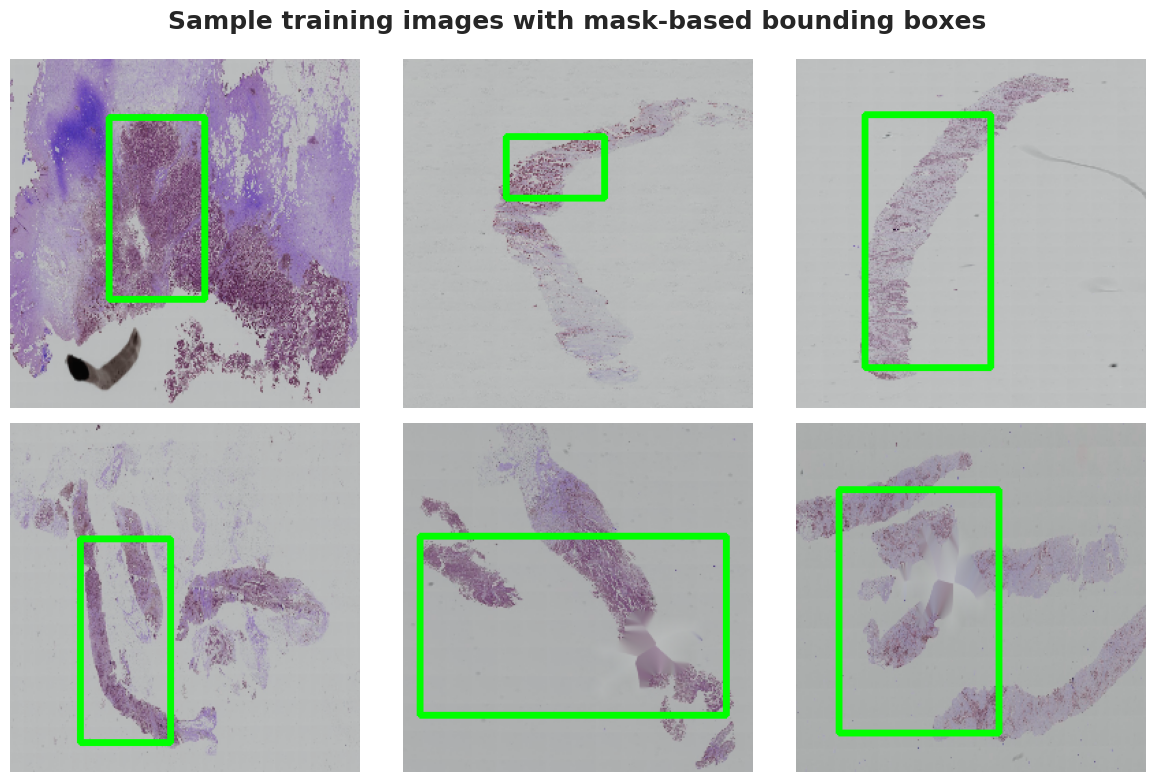

In [84]:
def visualize_samples_with_boxes(images, num_samples=6):
    """
    Visualize RGB + mask images with bounding boxes computed from channel 4
    """
    num_samples = min(num_samples, len(images))
    indices = np.random.choice(len(images), num_samples, replace=False)

    rows = 2
    cols = (num_samples + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Sample training images with mask-based bounding boxes",
                 fontsize=18, fontweight="bold")

    for i, idx in enumerate(indices):
        ax = axes[i]
        img = images[idx].copy()
        h, w, _ = img.shape

        # Extract mask from 4th channel
        mask = img[:, :, 3]

        # Compute bounding box from mask
        ys, xs = np.where(mask > 0)
        if len(xs) == 0 or len(ys) == 0:
            x1, y1, x2, y2 = 0, 0, 0, 0
        else:
            x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()

        # Draw rectangle on RGB only
        img_to_draw = img[:, :, :3].copy()
        if img_to_draw.dtype != np.uint8:
            img_to_draw = np.clip(img_to_draw, 0, 255).astype(np.uint8)

        cv2.rectangle(img_to_draw, (x1, y1), (x2, y2), (0, 255, 0), 3)
        ax.imshow(img_to_draw)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_samples_with_boxes(X_loc, num_samples=6)

In [85]:
# # 5. Visualisation helper
# # ============================================================

# def visualize_samples_with_boxes(images, boxes, num_samples=6):
#     num_samples = min(num_samples, len(images))
#     indices = np.random.choice(len(images), num_samples, replace=False)

#     rows = 2
#     cols = (num_samples + 1) // 2
#     fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
#     axes = np.array(axes).reshape(-1)

#     plt.suptitle("Sample training images with mask based bounding boxes",
#                  fontsize=18, fontweight="bold")

#     for i, idx in enumerate(indices):
#         ax = axes[i]
#         img = images[idx].copy()
#         box = boxes[idx]
#         h, w, _ = img.shape

#         x1, y1, x2, y2 = box
#         x1, y1, x2, y2 = int(x1 * w), int(y1 * h), int(x2 * w), int(y2 * h)

#         cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
#         ax.imshow(img)
#         ax.axis("off")

#     plt.tight_layout()
#     plt.show()


# visualize_samples_with_boxes(X_loc, y_boxes, num_samples=6)

In [86]:
import torchvision.transforms as T

normalize_rgb = T.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])

def normalize_4ch(img_tensor):
    # img_tensor shape: (C, H, W), C=4
    rgb = img_tensor[:3, :, :]/ 255.0 
    mask = img_tensor[3:, :, :]
    rgb = normalize_rgb(rgb)
    return torch.cat([rgb, mask], dim=0)


In [87]:
# 6. Dataset classes and DataLoaders
# ============================================================

class BoxDataset(Dataset):
    """
    Dataset for bounding box regression.

    images: numpy array (N, H, W, C)
    boxes: numpy array (N, 4) normalised coordinates
    """

    def __init__(self, images, boxes, augmentation=None):
        self.images = torch.from_numpy(images).float().permute(0, 3, 1, 2)
        self.boxes = torch.from_numpy(boxes).float()
        self.augmentation = augmentation
        self.normalize_rgb = T.Normalize(mean=[0.485, 0.456, 0.406],
                                                std=[0.229, 0.224, 0.225])
    def __len__(self):
        return len(self.images)

    
    def normalize_4ch(self, img_tensor):
        rgb = img_tensor[:3, :, :]/ 255.0 
        mask = img_tensor[3:, :, :]
        rgb = self.normalize_rgb(rgb)
        return torch.cat([rgb, mask], dim=0)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        box = self.boxes[idx].clone()

        if self.augmentation is not None:
            img = self.augmentation(img)

        img = self.normalize_4ch(img)
        return img, box


class ClassificationArrayDataset(Dataset):
    """
    Dataset for classification using preloaded numpy images and labels.
    labels must already be integer encoded.
    """

    def __init__(self, images, labels, augmentation=None):
        self.images = torch.from_numpy(images).float().permute(0, 3, 1, 2)
        self.labels = torch.from_numpy(labels).long()  # expects numeric labels
        self.augmentation = augmentation
        self.normalize_rgb = T.Normalize(mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.images)

    
    def normalize_4ch(self, img_tensor):
        rgb = img_tensor[:3, :, :]/ 255.0 
        mask = img_tensor[3:, :, :]
        rgb = self.normalize_rgb(rgb)
        return torch.cat([rgb, mask], dim=0)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        lbl = self.labels[idx].clone()

        if self.augmentation is not None:
            img = self.augmentation(img)

        img = self.normalize_4ch(img)
        return img, lbl


# ------------------------------------------------------------
# train/val split for localisation
# ------------------------------------------------------------
X_loc_train, X_loc_val, y_box_train, y_box_val = train_test_split(
    X_loc,
    y_boxes,
    test_size=0.2,
    random_state=SEED,
)

# ------------------------------------------------------------
# train/val split for classification (stratified on encoded labels)
# ------------------------------------------------------------
X_cls_train, X_cls_val, y_cls_train, y_cls_val = train_test_split(
    X_cls,
    y_cls_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_cls_encoded,
)

print("Localisation split:", len(X_loc_train), "train", len(X_loc_val), "val")
print("Classification split:", len(X_cls_train), "train", len(X_cls_val), "val")

# ------------------------------------------------------------
# augmentation
# ------------------------------------------------------------
train_aug = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5)])

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
train_box_loader = DataLoader(
    BoxDataset(X_loc_train, y_box_train, augmentation=train_aug),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_box_loader = DataLoader(
    BoxDataset(X_loc_val, y_box_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

train_cls_loader = DataLoader(
    ClassificationArrayDataset(X_cls_train, y_cls_train, augmentation=train_aug),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_cls_loader = DataLoader(
    ClassificationArrayDataset(X_cls_val, y_cls_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Regression batches:", len(train_box_loader), "train", len(val_box_loader), "val")
print("Classification batches:", len(train_cls_loader), "train", len(val_cls_loader), "val")

Localisation split: 991 train 248 val
Classification split: 991 train 248 val
Regression batches: 16 train 4 val
Classification batches: 16 train 4 val


In [88]:
# ============================================================
# 7. Models
# ============================================================

class BoxRegressorModel(nn.Module):
    """
    Bounding box regressor on top of EfficientNetB0.
    Predicts 4 normalised coordinates: x1, y1, x2, y2.
    """

    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        
        # --- Modify first conv layer to accept 4 channels ---
        old_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels=4,                    # 4 channels now
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None
        )

        # Copy pretrained weights for first 3 channels
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            new_conv.weight[:, 3:4, :, :] = 0.0  # initialize mask channel to zeros

        self.backbone.features[0][0] = new_conv
        # -----------------------------------------------------

        # Freeze backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 4),
        )

    def forward(self, x):
        return self.backbone(x)


class ClassifierModel(nn.Module):
    """
    Image classifier based on EfficientNetB0.
    """

    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        # --- Modify first conv layer to accept 4 channels ---
        old_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels=4,                    # 4 channels now
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None
        )

        # Copy pretrained weights for first 3 channels
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            new_conv.weight[:, 3:4, :, :] = 0.0  # initialize mask channel to zeros

        self.backbone.features[0][0] = new_conv
        # -----------------------------------------------------

        # Freeze backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


box_model = BoxRegressorModel().to(device)
cls_model = ClassifierModel(num_classes=num_classes).to(device)

print("Box regressor parameters:", sum(p.numel() for p in box_model.parameters()))
print("Classifier parameters:", sum(p.numel() for p in cls_model.parameters()))

Box regressor parameters: 4012960
Classifier parameters: 4012960


In [89]:
# ============================================================
# 8. Training helpers – localisation
# ============================================================

def train_box_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum = 0.0
    for img, box in loader:
        img = img.to(device)
        box = box.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            pred = model(img)
            loss = criterion(pred, box)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * img.size(0)

    return loss_sum / len(loader.dataset)


def val_box_epoch(model, loader, criterion):
    model.eval()
    loss_sum = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, box in loader:
            img = img.to(device)
            box = box.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                pred = model(img)
                loss = criterion(pred, box)

            loss_sum += loss.item() * img.size(0)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(box.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    rho = float(spearman_rho(all_preds, all_targets))
    return loss_sum / len(loader.dataset), rho


def fit_box_regressor(model, train_loader, val_loader, epochs, criterion, optimizer,
                      scaler, patience, model_name):
    history = {"train_loss": [], "val_loss": [], "val_spearman": []}
    best_loss = float("inf")
    patience_counter = 0
    best_epoch = 0

    print(f"Training box regressor: {model_name}")

    for epoch in range(1, epochs + 1):
        train_loss = train_box_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_rho = val_box_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_spearman"].append(val_rho)

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train MSE {train_loss:.4f} | "
                f"Val MSE {val_loss:.4f} | "
                f"Val Spearman {val_rho:.4f}"
            )

        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{model_name}.pt"))
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Best val MSE {best_loss:.4f} at epoch {best_epoch}")
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{model_name}.pt")))
    return model, history

In [90]:
# ============================================================
# 9. Training helpers – classification
# ============================================================

def train_cls_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum = 0.0
    acc_list = []

    for img, lbl in loader:
        img = img.to(device)
        lbl = lbl.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            out = model(img)
            loss = criterion(out, lbl)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * img.size(0)
        preds = out.argmax(dim=1).cpu().numpy()
        acc_list.append(accuracy_score(lbl.cpu().numpy(), preds))

    return loss_sum / len(loader.dataset), float(np.mean(acc_list))


def val_cls_epoch(model, loader, criterion):
    """
    Validate classifier for one epoch.

    Returns:
        avg_loss, avg_accuracy, macro_f1
    """
    model.eval()
    loss_sum = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, lbl in loader:
            img, lbl = img.to(device), lbl.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                out = model(img)
                loss = criterion(out, lbl)

            loss_sum += loss.item() * img.size(0)

            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(lbl.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, average="macro")

    return loss_sum / len(loader.dataset), val_acc, val_f1


def fit_classifier(model, train_loader, val_loader, epochs, criterion, optimizer,
                   scaler, patience, model_name):
    history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': []          # new
}
    best_f1 = -1.0
    patience_counter = 0
    best_epoch = 0

    print(f"Training classifier: {model_name}")

    for epoch in range(1, epochs + 1):
        # Training phase
        train_loss, train_acc = train_cls_epoch(model, train_loader, criterion, optimizer, scaler)

        # Validation phase
        val_loss, val_acc, val_f1 = val_cls_epoch(model, val_loader, criterion)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)



        # Print progress
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
            )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{model_name}.pt"))
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Best val F1 {best_f1:.4f} at epoch {best_epoch}")
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{model_name}.pt")))
    return model, history

In [91]:
# ============================================================
# 10. Train box regressor
# ============================================================
#CHANGED
box_optimizer = torch.optim.AdamW(
    box_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4  # good default
)

box_criterion = nn.MSELoss()
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

box_model, box_history = fit_box_regressor(
    model=box_model,
    train_loader=train_box_loader,
    val_loader=val_box_loader,
    epochs=EPOCHS,
    criterion=box_criterion,
    optimizer=box_optimizer,
    scaler=scaler,
    patience=PATIENCE,
    model_name="efficientnet_box_regressor",
)

Training box regressor: efficientnet_box_regressor
Epoch   1/1000 | Train MSE 0.0676 | Val MSE 0.0227 | Val Spearman -0.0186
Epoch   5/1000 | Train MSE 0.0142 | Val MSE 0.0061 | Val Spearman -0.0252
Epoch  10/1000 | Train MSE 0.0027 | Val MSE 0.0007 | Val Spearman -0.0214
Epoch  15/1000 | Train MSE 0.0003 | Val MSE 0.0001 | Val Spearman -0.0489
Epoch  20/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman -0.0335
Epoch  25/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman 0.0118
Epoch  30/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman -0.0624
Epoch  35/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman -0.0487
Epoch  40/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman -0.0033
Epoch  45/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman -0.0418
Epoch  50/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman 0.0071
Epoch  55/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearman 0.0036
Epoch  60/1000 | Train MSE 0.0000 | Val MSE 0.0000 | Val Spearma

---

INSPECTION OF THE RESULTS

In [92]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_classifier_predictions(model, images, labels, class_names, device, num_samples=6):
    model.eval()
    indices = np.random.choice(len(images), num_samples, replace=False)
    fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))
    
    for i, idx in enumerate(indices):
        img = images[idx]
        lbl = labels[idx]

        # Convert to tensor and move to device
        img_tensor = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0).to(device)
        
        with torch.no_grad():
            logits = model(img_tensor)
            pred_class = logits.argmax(dim=1).item()

        ax = axes[i]
        ax.imshow(img[:,:,:3].astype(np.uint8))  # only RGB for display
        ax.set_title(f"True: {class_names[lbl]}\nPred: {class_names[pred_class]}")
        ax.axis("off")
    plt.show()


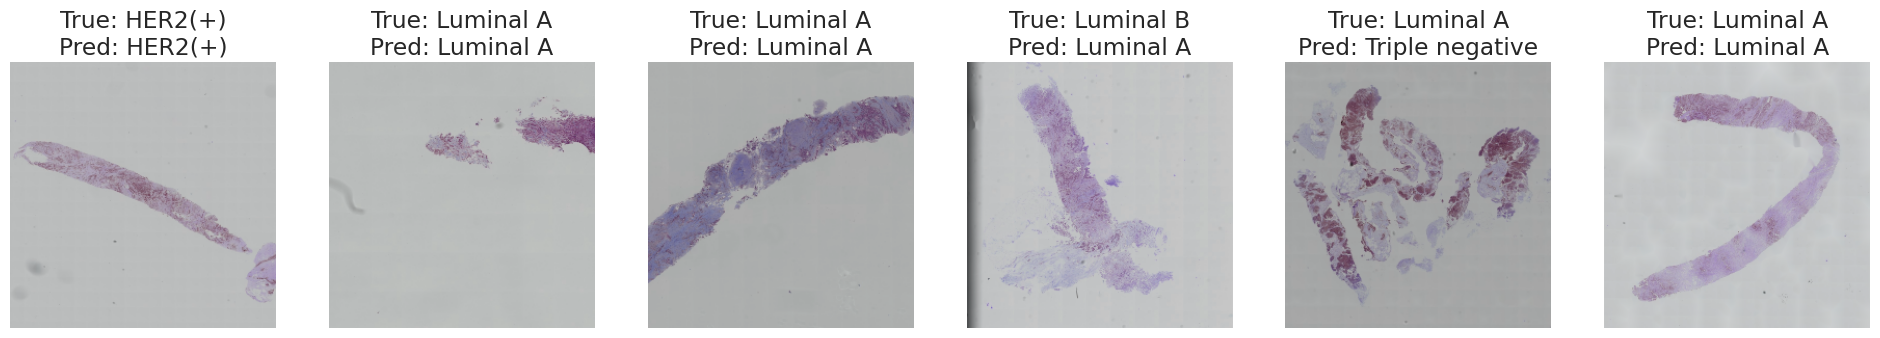

In [93]:
visualize_classifier_predictions(cls_model, X_cls_val, y_cls_val, class_names, device)


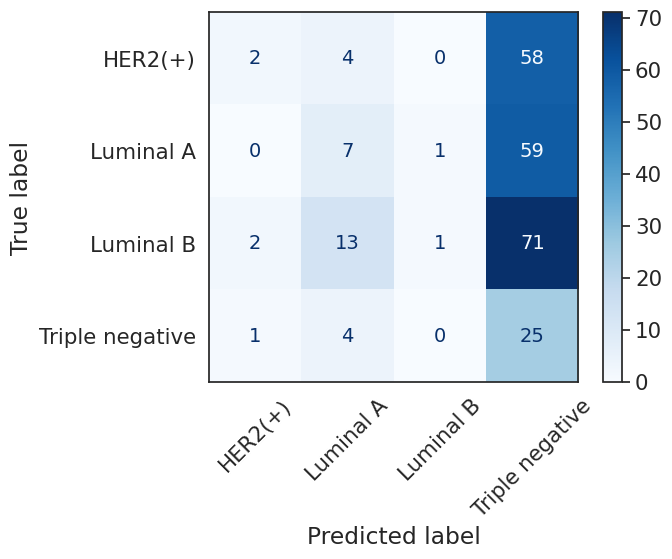

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cls_model.eval()
all_preds = []
all_labels = []

for img, lbl in val_cls_loader:
    img, lbl = img.to(device), lbl.to(device)
    with torch.no_grad():
        logits = cls_model(img)
        preds = logits.argmax(dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(lbl.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.show()


In [95]:
from sklearn.metrics import f1_score, classification_report

cls_model.eval()
all_preds = []
all_labels = []

for img, lbl in val_cls_loader:
    img, lbl = img.to(device), lbl.to(device)
    with torch.no_grad():
        logits = cls_model(img)
        preds = logits.argmax(dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(lbl.cpu().numpy())


In [96]:
# Macro F1: average across classes equally
f1_macro = f1_score(all_labels, all_preds, average='macro')
print(f"Macro F1 score: {f1_macro:.4f}")

# Weighted F1: weighted by number of samples per class
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print(f"Weighted F1 score: {f1_weighted:.4f}")


Macro F1 score: 0.1084
Weighted F1 score: 0.0875


In [97]:
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
                 precision    recall  f1-score   support

        HER2(+)       0.40      0.03      0.06        64
      Luminal A       0.25      0.10      0.15        67
      Luminal B       0.50      0.01      0.02        87
Triple negative       0.12      0.83      0.21        30

       accuracy                           0.14       248
      macro avg       0.32      0.25      0.11       248
   weighted avg       0.36      0.14      0.09       248



                 precision    recall  f1-score   support

        HER2(+)       0.40      0.03      0.06        64
      Luminal A       0.25      0.10      0.15        67
      Luminal B       0.50      0.01      0.02        87
Triple negative       0.12      0.83      0.21        30

       accuracy                           0.14       248
      macro avg       0.32      0.25      0.11       248
   weighted avg       0.36      0.14      0.09       248



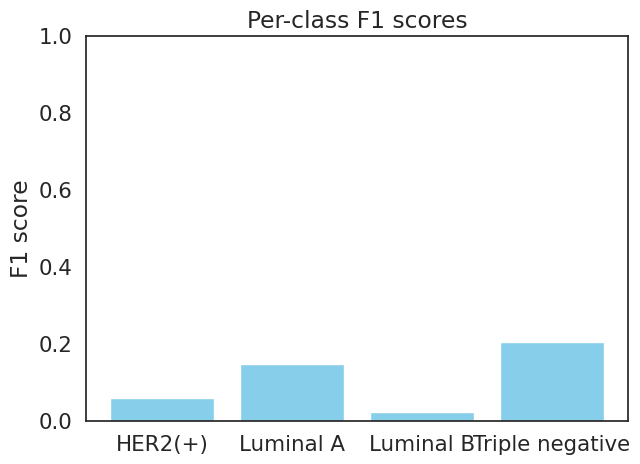

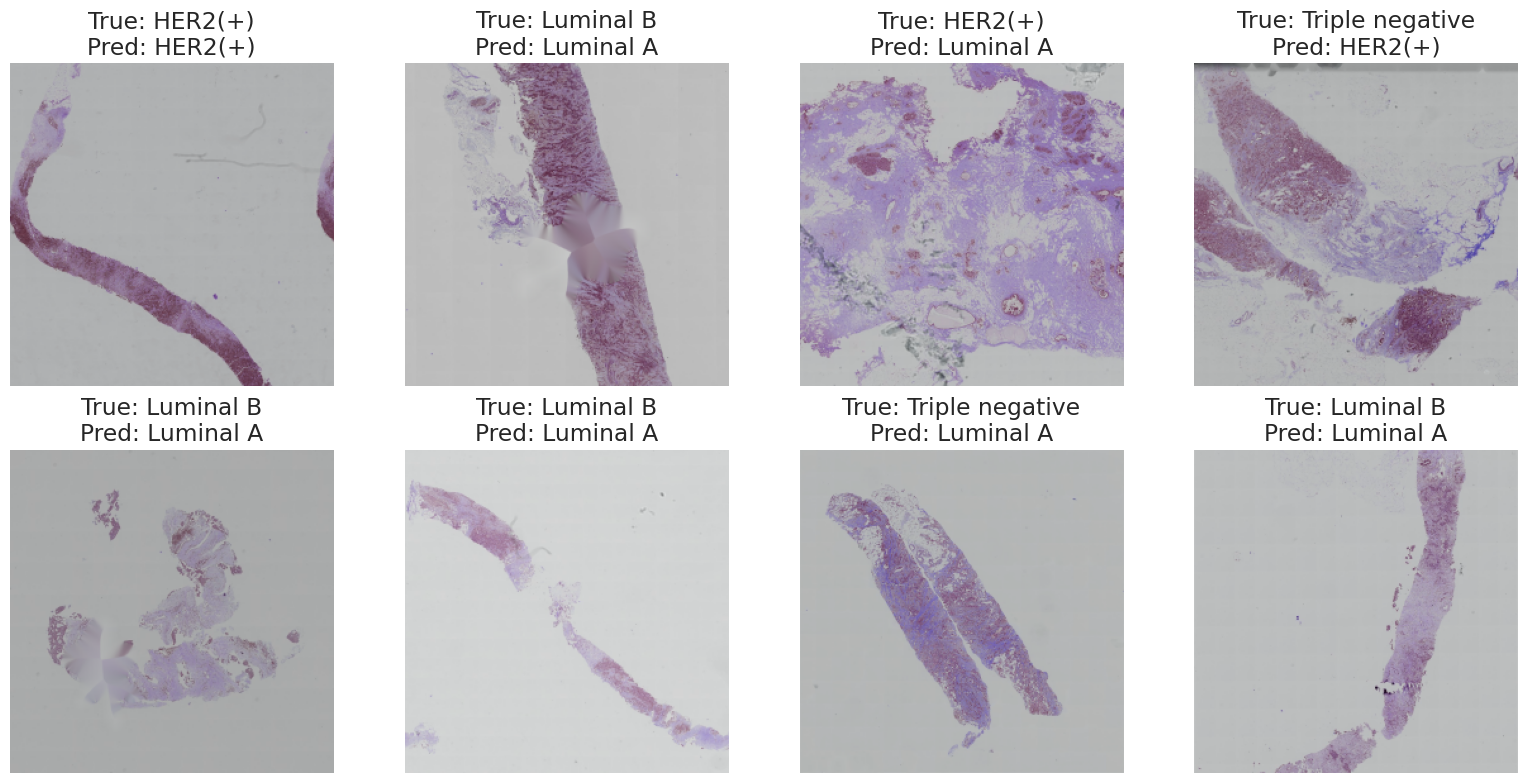

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

# -------------------------------
# 1. Compute F1 per class
# -------------------------------
cls_model.eval()
all_preds = []
all_labels = []

for img, lbl in val_cls_loader:
    img, lbl = img.to(device), lbl.to(device)
    with torch.no_grad():
        logits = cls_model(img)
        preds = logits.argmax(dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(lbl.cpu().numpy())

# Detailed classification report
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------------------
# 2. Plot per-class F1 scores
# -------------------------------
f1_scores = [report[c]['f1-score'] for c in class_names]

plt.figure(figsize=(7,5))
plt.bar(class_names, f1_scores, color='skyblue')
plt.ylabel('F1 score')
plt.title('Per-class F1 scores')
plt.ylim(0,1)
plt.show()

# -------------------------------
# 3. Visualize sample predictions
# -------------------------------
import numpy as np
import torch

def visualize_samples(model, images, labels, class_names, device, num_samples=8):
    model.eval()
    indices = np.random.choice(len(images), num_samples, replace=False)
    fig, axes = plt.subplots(2, (num_samples+1)//2, figsize=(4*((num_samples+1)//2), 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img = images[idx]
        lbl = labels[idx]
        img_tensor = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor).argmax(dim=1).item()
        
        axes[i].imshow(img[:,:,:3].astype(np.uint8))  # show RGB only
        axes[i].set_title(f"True: {class_names[lbl]}\nPred: {class_names[pred]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Call function
visualize_samples(cls_model, X_cls_val, y_cls_val, class_names, device)


In [99]:
print("X_loc shape:", X_loc.shape, "dtype:", X_loc.dtype)
print("X_cls shape:", X_cls.shape, "dtype:", X_cls.dtype)

# Example for a single image
print("Sample image shape:", X_cls[0].shape)
print("Sample pixel values min/max:", X_cls[0].min(), X_cls[0].max())


X_loc shape: (1239, 256, 256, 4) dtype: uint8
X_cls shape: (1239, 256, 256, 4) dtype: uint8
Sample image shape: (256, 256, 4)
Sample pixel values min/max: 0 255


In [100]:
print("y_boxes shape:", y_boxes.shape, "dtype:", y_boxes.dtype)
print("First 5 bounding boxes:\n", y_boxes[:5])


y_boxes shape: (1239, 4) dtype: float32
First 5 bounding boxes:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [101]:
print("Encoded labels shape:", y_cls_encoded.shape)
print("Sample encoded labels:", y_cls_encoded[:10])
print("Class mapping (int -> name):", dict(enumerate(class_names)))


Encoded labels shape: (1239,)
Sample encoded labels: [3 1 1 2 0 2 2 1 3 2]
Class mapping (int -> name): {0: 'HER2(+)', 1: 'Luminal A', 2: 'Luminal B', 3: 'Triple negative'}


---

In [102]:
# ============================================================
# 11. Train classifier (frozen backbone)
# ============================================================
#CHANGED
cls_optimizer = torch.optim.AdamW(
    cls_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4  # or 5e-5
)

cls_criterion = nn.CrossEntropyLoss()

cls_model, cls_history = fit_classifier(
    model=cls_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    epochs=EPOCHS,
    criterion=cls_criterion,
    optimizer=cls_optimizer,
    scaler=scaler,
    patience=30,
    model_name="efficientnet_classifier",
)

Training classifier: efficientnet_classifier
Epoch   1/1000 | Train Loss: 1.3796 | Train Acc: 0.3129 | Val Loss: 1.3469 | Val Acc: 0.3185 | Val F1: 0.1697
Epoch   5/1000 | Train Loss: 1.2660 | Train Acc: 0.4165 | Val Loss: 1.3288 | Val Acc: 0.3387 | Val F1: 0.2373
Epoch  10/1000 | Train Loss: 1.2281 | Train Acc: 0.4323 | Val Loss: 1.3633 | Val Acc: 0.3548 | Val F1: 0.2625
Epoch  15/1000 | Train Loss: 1.1955 | Train Acc: 0.4637 | Val Loss: 1.3467 | Val Acc: 0.3790 | Val F1: 0.2855
Epoch  20/1000 | Train Loss: 1.1473 | Train Acc: 0.4795 | Val Loss: 1.3906 | Val Acc: 0.3669 | Val F1: 0.2749
Epoch  25/1000 | Train Loss: 1.1266 | Train Acc: 0.5021 | Val Loss: 1.3605 | Val Acc: 0.3589 | Val F1: 0.2824
Epoch  30/1000 | Train Loss: 1.1209 | Train Acc: 0.5087 | Val Loss: 1.3631 | Val Acc: 0.3468 | Val F1: 0.2762
Epoch  35/1000 | Train Loss: 1.1259 | Train Acc: 0.5155 | Val Loss: 1.3781 | Val Acc: 0.3387 | Val F1: 0.2601
Epoch  40/1000 | Train Loss: 1.1163 | Train Acc: 0.5177 | Val Loss: 1.3884 

In [122]:
# ============================================================
# 12. Optional fine tuning (unfreeze last blocks)
# ============================================================

def unfreeze_last_blocks(model, num_blocks=3):
    """
    Unfreeze last num_blocks of EfficientNet features for fine tuning.
    """
    for param in model.backbone.features[-num_blocks:].parameters():
        param.requires_grad = True

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("Unfrozen last", num_blocks, "blocks")
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print(f"Trainable percentage: {100 * trainable_params / total_params:.1f}%")
    return model


cls_model = unfreeze_last_blocks(cls_model, num_blocks=3)

#CHANGED
ft_optimizer = torch.optim.AdamW(
    cls_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,   # Good default for fine-tuning
    betas=(0.9, 0.999)   # Standard
)
ft_criterion = nn.CrossEntropyLoss()

cls_model, ft_history = fit_classifier(
    model=cls_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    epochs=EPOCHS,
    criterion=ft_criterion,
    optimizer=ft_optimizer,
    scaler=scaler,
    patience=30,
    model_name="efficientnet_classifier_finetuned",
)

Unfrozen last 3 blocks
Total params: 4,012,960
Trainable params: 3,160,864
Trainable percentage: 78.8%
Training classifier: efficientnet_classifier_finetuned
Epoch   1/1000 | Train Loss: 0.6145 | Train Acc: 0.7916 | Val Loss: 1.5240 | Val Acc: 0.3750 | Val F1: 0.3366
Epoch   5/1000 | Train Loss: 0.4215 | Train Acc: 0.8794 | Val Loss: 1.5824 | Val Acc: 0.3669 | Val F1: 0.3203
Epoch  10/1000 | Train Loss: 0.2722 | Train Acc: 0.9255 | Val Loss: 1.7440 | Val Acc: 0.3911 | Val F1: 0.3613
Epoch  15/1000 | Train Loss: 0.1963 | Train Acc: 0.9421 | Val Loss: 1.9004 | Val Acc: 0.3790 | Val F1: 0.3542
Epoch  20/1000 | Train Loss: 0.1439 | Train Acc: 0.9520 | Val Loss: 2.0756 | Val Acc: 0.3629 | Val F1: 0.3430
Epoch  25/1000 | Train Loss: 0.1149 | Train Acc: 0.9706 | Val Loss: 2.2923 | Val Acc: 0.3710 | Val F1: 0.3414
Epoch  30/1000 | Train Loss: 0.0834 | Train Acc: 0.9755 | Val Loss: 2.4038 | Val Acc: 0.3871 | Val F1: 0.3741
Epoch  35/1000 | Train Loss: 0.0851 | Train Acc: 0.9755 | Val Loss: 2.82

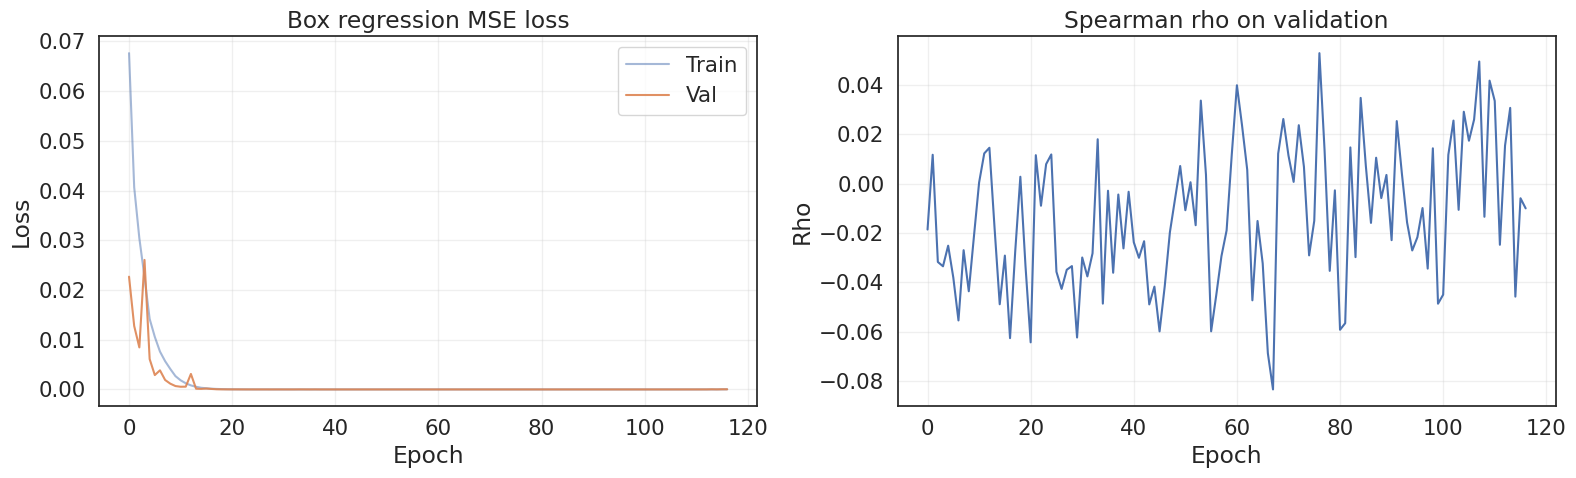

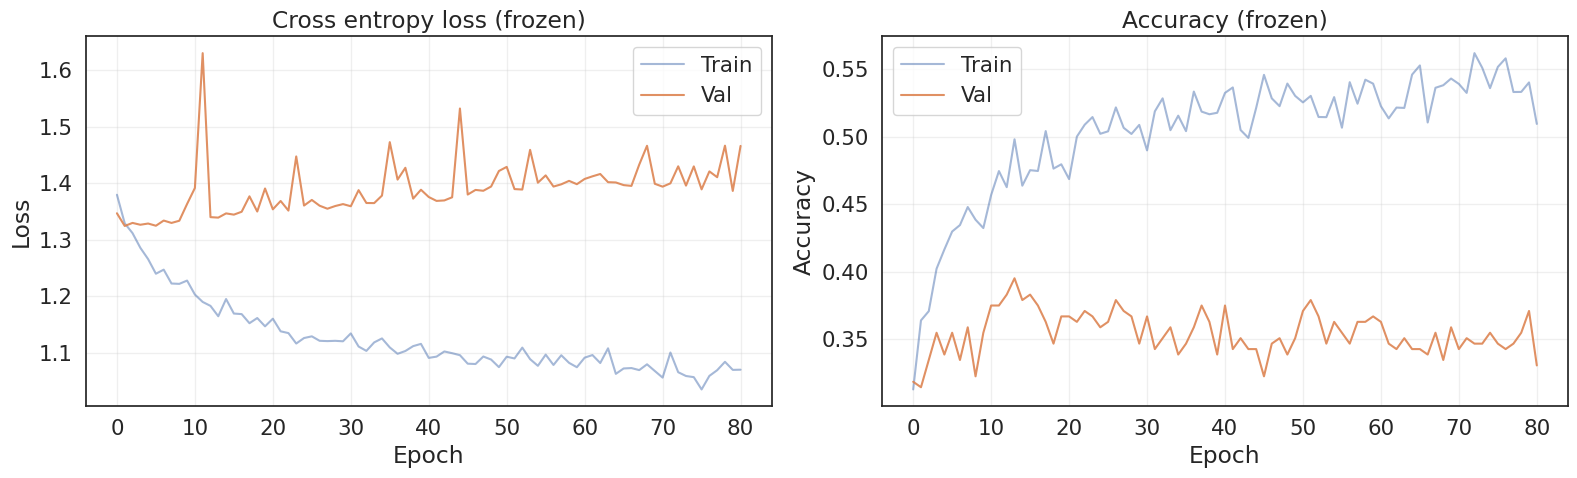

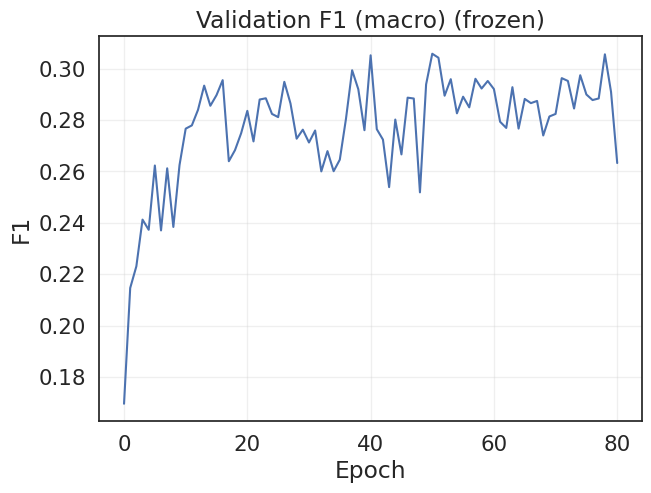

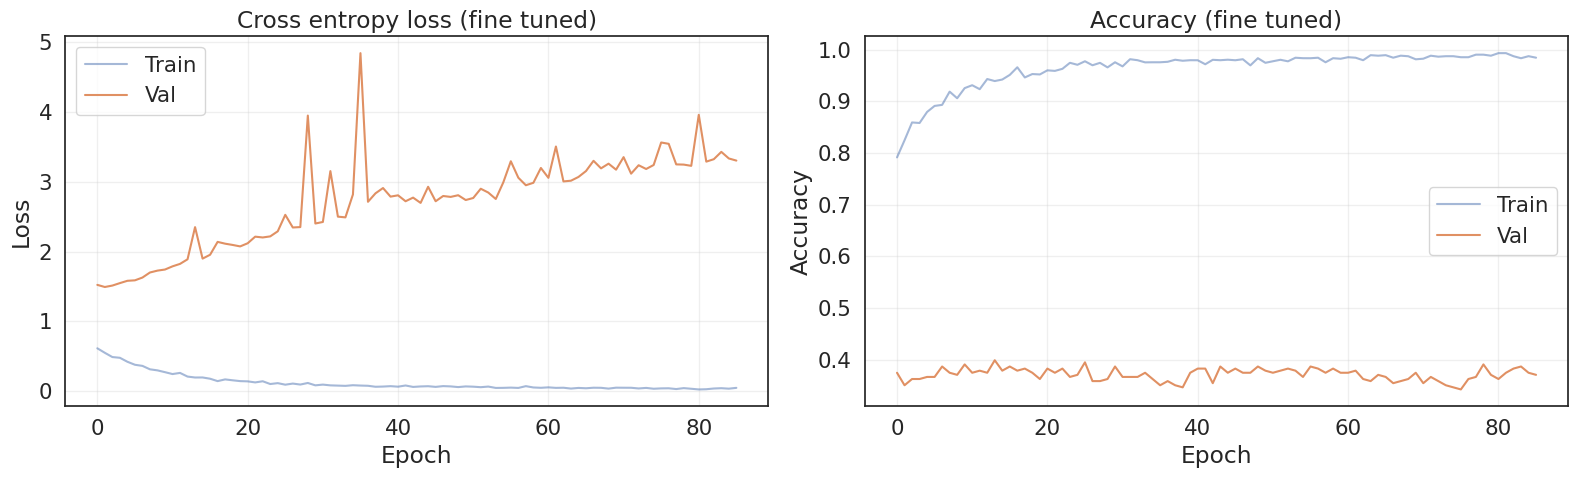

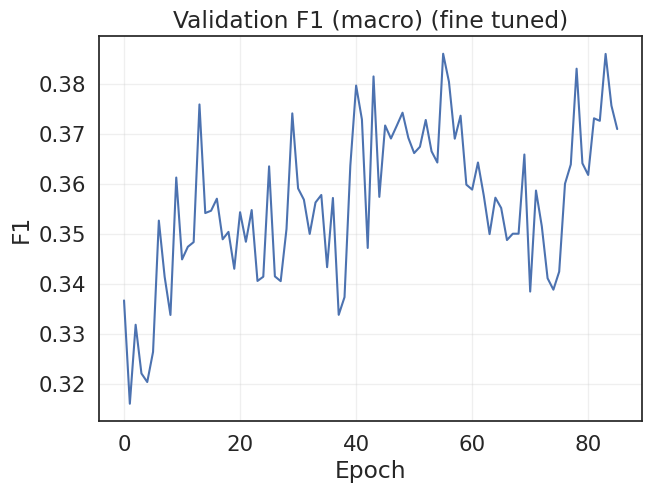

In [128]:
# ============================================================
# 13. Plot training curves
# ============================================================

def plot_history_box(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(history["train_loss"], label="Train", alpha=0.5)
    ax1.plot(history["val_loss"], label="Val", alpha=0.9)
    ax1.set_title("Box regression MSE loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history["val_spearman"])
    ax2.set_title("Spearman rho on validation")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Rho")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_history_cls(history, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(history["train_loss"], label="Train", alpha=0.5)
    ax1.plot(history["val_loss"], label="Val", alpha=0.9)
    ax1.set_title(f"Cross entropy loss{title_suffix}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history["train_acc"], label="Train", alpha=0.5)
    ax2.plot(history["val_acc"], label="Val", alpha=0.9)
    ax2.set_title(f"Accuracy{title_suffix}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # F1 plot for this specific history
    plt.figure(figsize=(7, 5))
    plt.plot(history["val_f1"])
    plt.title(f"Validation F1 (macro){title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.grid(alpha=0.3)
    plt.show()


plot_history_box(box_history)
plot_history_cls(cls_history, title_suffix=" (frozen)")
plot_history_cls(ft_history, title_suffix=" (fine tuned)")

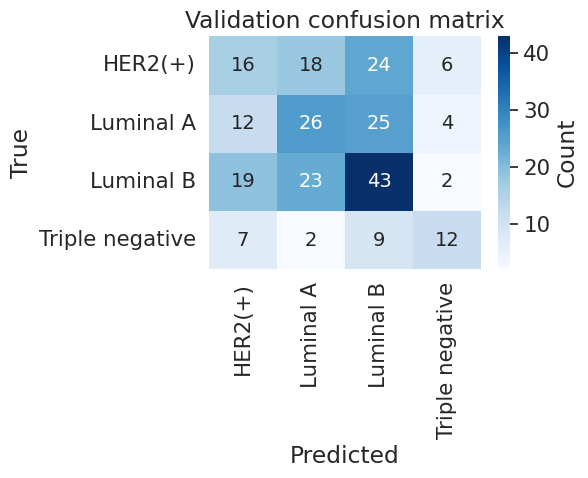

In [124]:
# ============================================================
# 14. Confusion matrix on validation
# ============================================================

def plot_confusion_matrix_model(model, loader, class_names):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, lbl in loader:
            img = img.to(device)
            lbl = lbl.to(device)
            out = model(img)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(lbl.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Count"},
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Validation confusion matrix")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix_model(cls_model, val_cls_loader, class_names)

In [141]:
# ============================================================
# 15. Test set inference (classification + localisation)
# ============================================================

def load_test_images(img_dir, img_dim):
    # only keep real images, ignore mask_XXXX.png
    files = sorted(
        [
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".tiff", ".tif", ".png", ".jpg", ".jpeg"))
            and f.startswith("img_")
        ]
    )
    images = []
    names = []
    for fname in files:
        img_path = os.path.join(img_dir, fname)
        img = cv2.imread(img_path,  cv2.IMREAD_UNCHANGED)
        
        if img is None:
            continue
            
        # handle grayscale TIFFs (1-channel)
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            print("ALARM! NDIM = 2")

        # handle RGBA TIFFs (4-channel → RGB)
        if img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)

        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape
            mask = np.zeros((h, w, 1), dtype=img.dtype)
            img = np.concatenate([img, mask], axis=2)
            print("ALARM!PIZDETZ")


            
        # 4. Ensure always 4 channels
        assert img.shape[2] == 4, f"Expected 4 channels, got {img.shape}"
        
        img = cv2.resize(img, (img_dim, img_dim))
        
        images.append(img)
        names.append(fname)
        
    images = np.array(images)
    return images, names

X_test_raw, test_names = load_test_images(TEST_IMG_DIR, IMG_SIZE)
print("Loaded test images:", len(X_test_raw))

transform_test = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=False),
])

X_test_tensor = []

for img in X_test_raw:
    img_t = transform_test(Image.fromarray(img))   # → float tensor [4,H,W]
    img_t = normalize_4ch(img_t)                   # normalize RGB only
    X_test_tensor.append(img_t)

X_test_tensor = torch.stack(X_test_tensor)


print("Test tensor shape:", X_test_tensor.shape)

cls_model.eval()
box_model.eval()

cls_probs_list = []
box_preds_list = []

BATCH_SIZE_TEST = BATCH_SIZE  # or set a specific value like 32

with torch.no_grad():
    for start in range(0, len(X_test_tensor), BATCH_SIZE_TEST):
        end = start + BATCH_SIZE_TEST
        batch = X_test_tensor[start:end].to(device)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda"),
        ):
            cls_logits = cls_model(batch)
            box_batch = box_model(batch)

        cls_probs_list.append(torch.softmax(cls_logits, dim=1).cpu().numpy())
        box_preds_list.append(box_batch.cpu().numpy())

cls_probs = np.concatenate(cls_probs_list, axis=0)
box_preds = np.concatenate(box_preds_list, axis=0)

print("Inference done on test set.")

Loaded test images: 954
Test tensor shape: torch.Size([954, 4, 256, 256])
Inference done on test set.


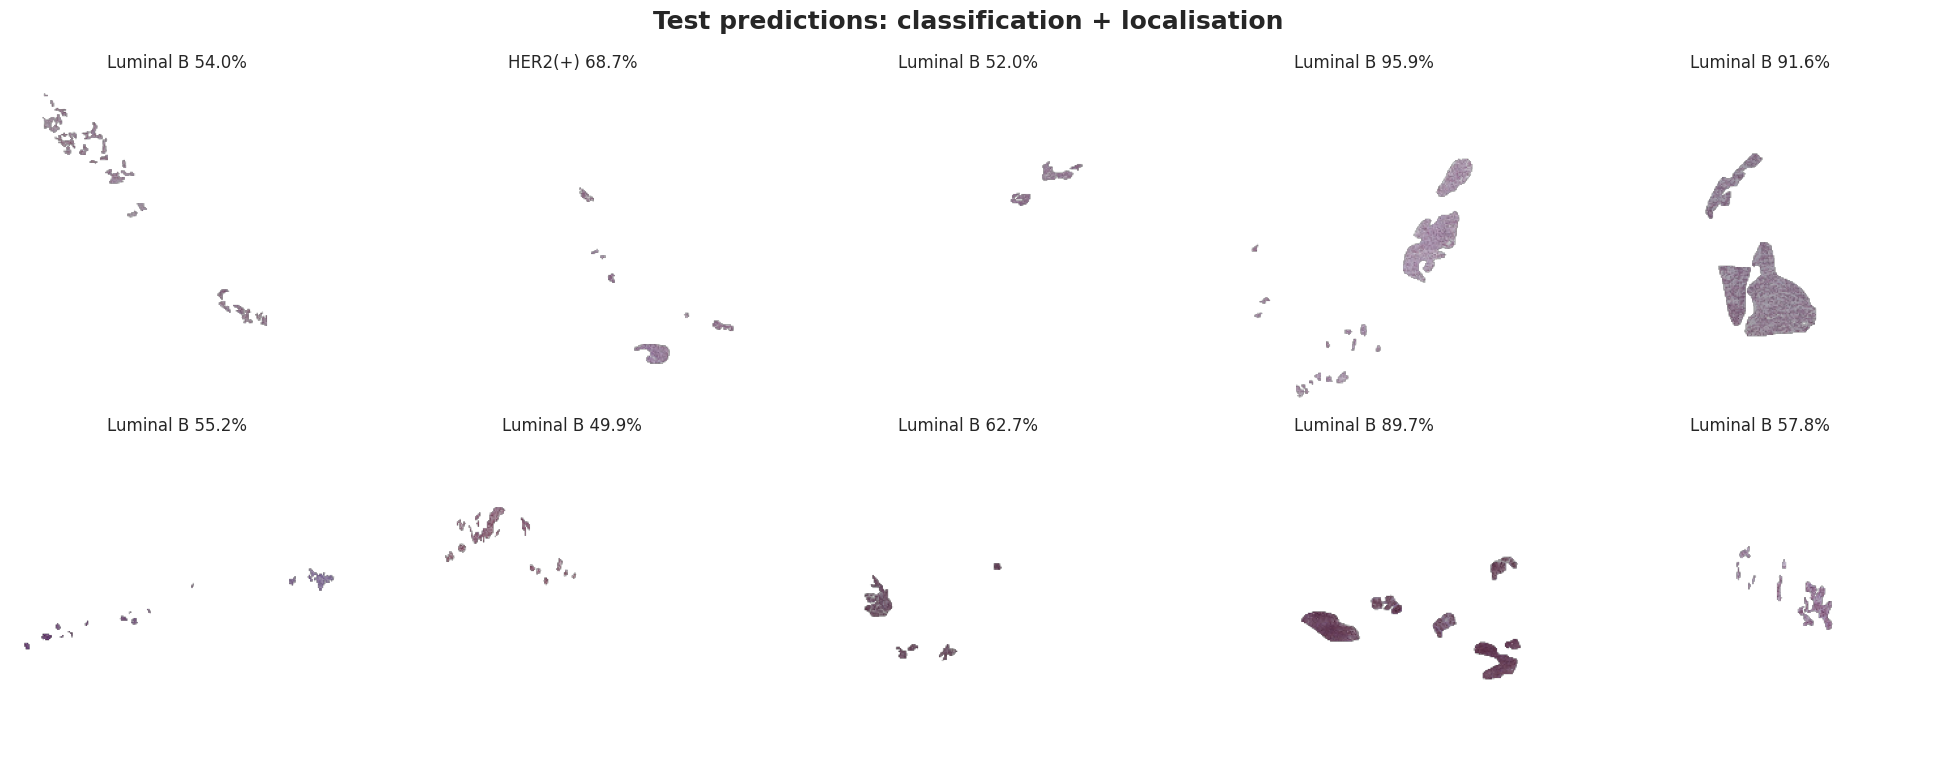

In [130]:
# ============================================================
# 16. Visualise combined predictions
# ============================================================

def visualize_test_predictions(images, cls_probs, box_preds, class_names, max_images=10):
    num_img = len(images)
    n = min(max_images, num_img)
    rows = 2
    cols = (n + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Test predictions: classification + localisation",
                 fontsize=18, fontweight="bold")

    for i in range(n):
        ax = axes[i]
        img = images[i].copy()
        h, w, _ = img.shape

        bx = box_preds[i]
        x1 = int(bx[0] * w)
        y1 = int(bx[1] * h)
        x2 = int(bx[2] * w)
        y2 = int(bx[3] * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

        lbl_idx = int(np.argmax(cls_probs[i]))
        conf = float(cls_probs[i][lbl_idx] * 100)
        lbl_name = class_names[lbl_idx]

        ax.imshow(img)
        ax.set_title(f"{lbl_name} {conf:.1f}%", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_test_predictions(X_test_raw, cls_probs, box_preds, class_names, max_images=10)

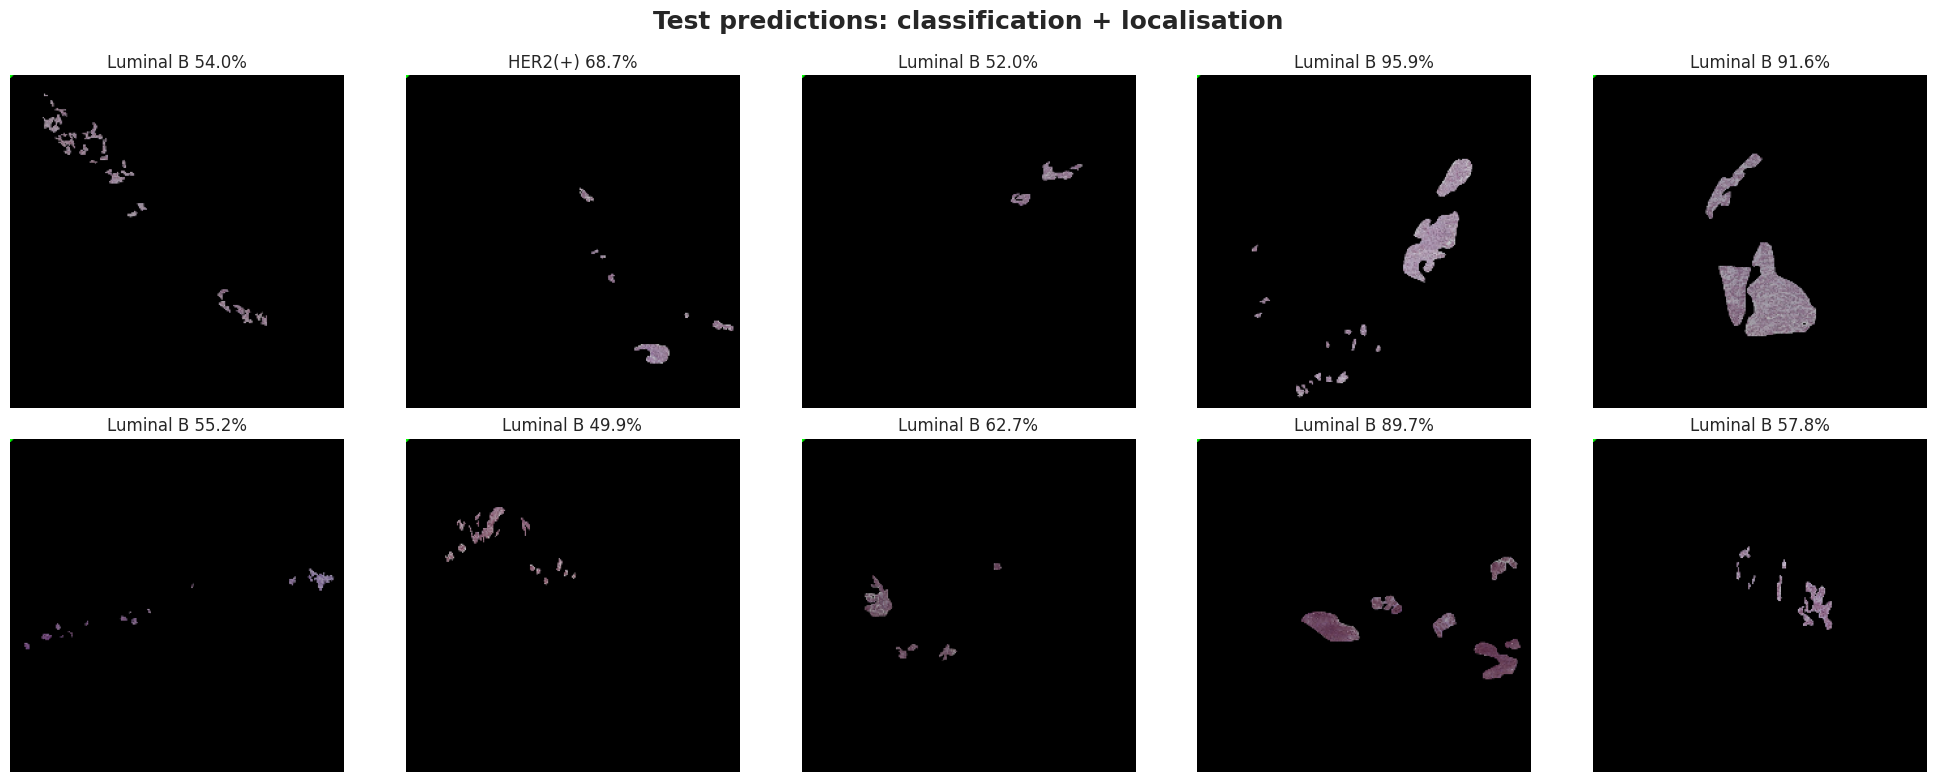

In [131]:
def visualize_test_predictions(images, cls_probs, box_preds, class_names, max_images=10):
    """
    Visualizes predictions for 4-channel TIFF images.
    The mask channel is ignored for visualization (only RGB is shown).
    """
    num_img = len(images)
    n = min(max_images, num_img)
    rows = 2
    cols = (n + 1) // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Test predictions: classification + localisation",
                 fontsize=18, fontweight="bold")

    for i in range(n):
        ax = axes[i]

        # --- handle RGBA image (H,W,4) ---
        img = images[i]

        if img.shape[2] == 4:
            rgb = img[:, :, :3]        # drop mask/alpha
        elif img.shape[2] == 3:
            rgb = img
        else:
            raise ValueError(f"Unexpected channel count: {img.shape}")

        rgb = rgb.astype(np.uint8)

        h, w, _ = rgb.shape

        # --- bounding box ---
        bx = box_preds[i]
        x1 = int(bx[0] * w)
        y1 = int(bx[1] * h)
        x2 = int(bx[2] * w)
        y2 = int(bx[3] * h)

        # Draw box
        rgb_box = rgb.copy()
        cv2.rectangle(rgb_box, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # --- classification label ---
        lbl_idx = int(np.argmax(cls_probs[i]))
        conf = float(cls_probs[i][lbl_idx] * 100)
        lbl_name = class_names[lbl_idx]

        ax.imshow(rgb_box)
        ax.set_title(f"{lbl_name} {conf:.1f}%", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_test_predictions(X_test_raw, cls_probs, box_preds, class_names, max_images=10)

In [109]:
print("min:", box_preds.min(), "max:", box_preds.max())


min: -0.0005198 max: 0.002325


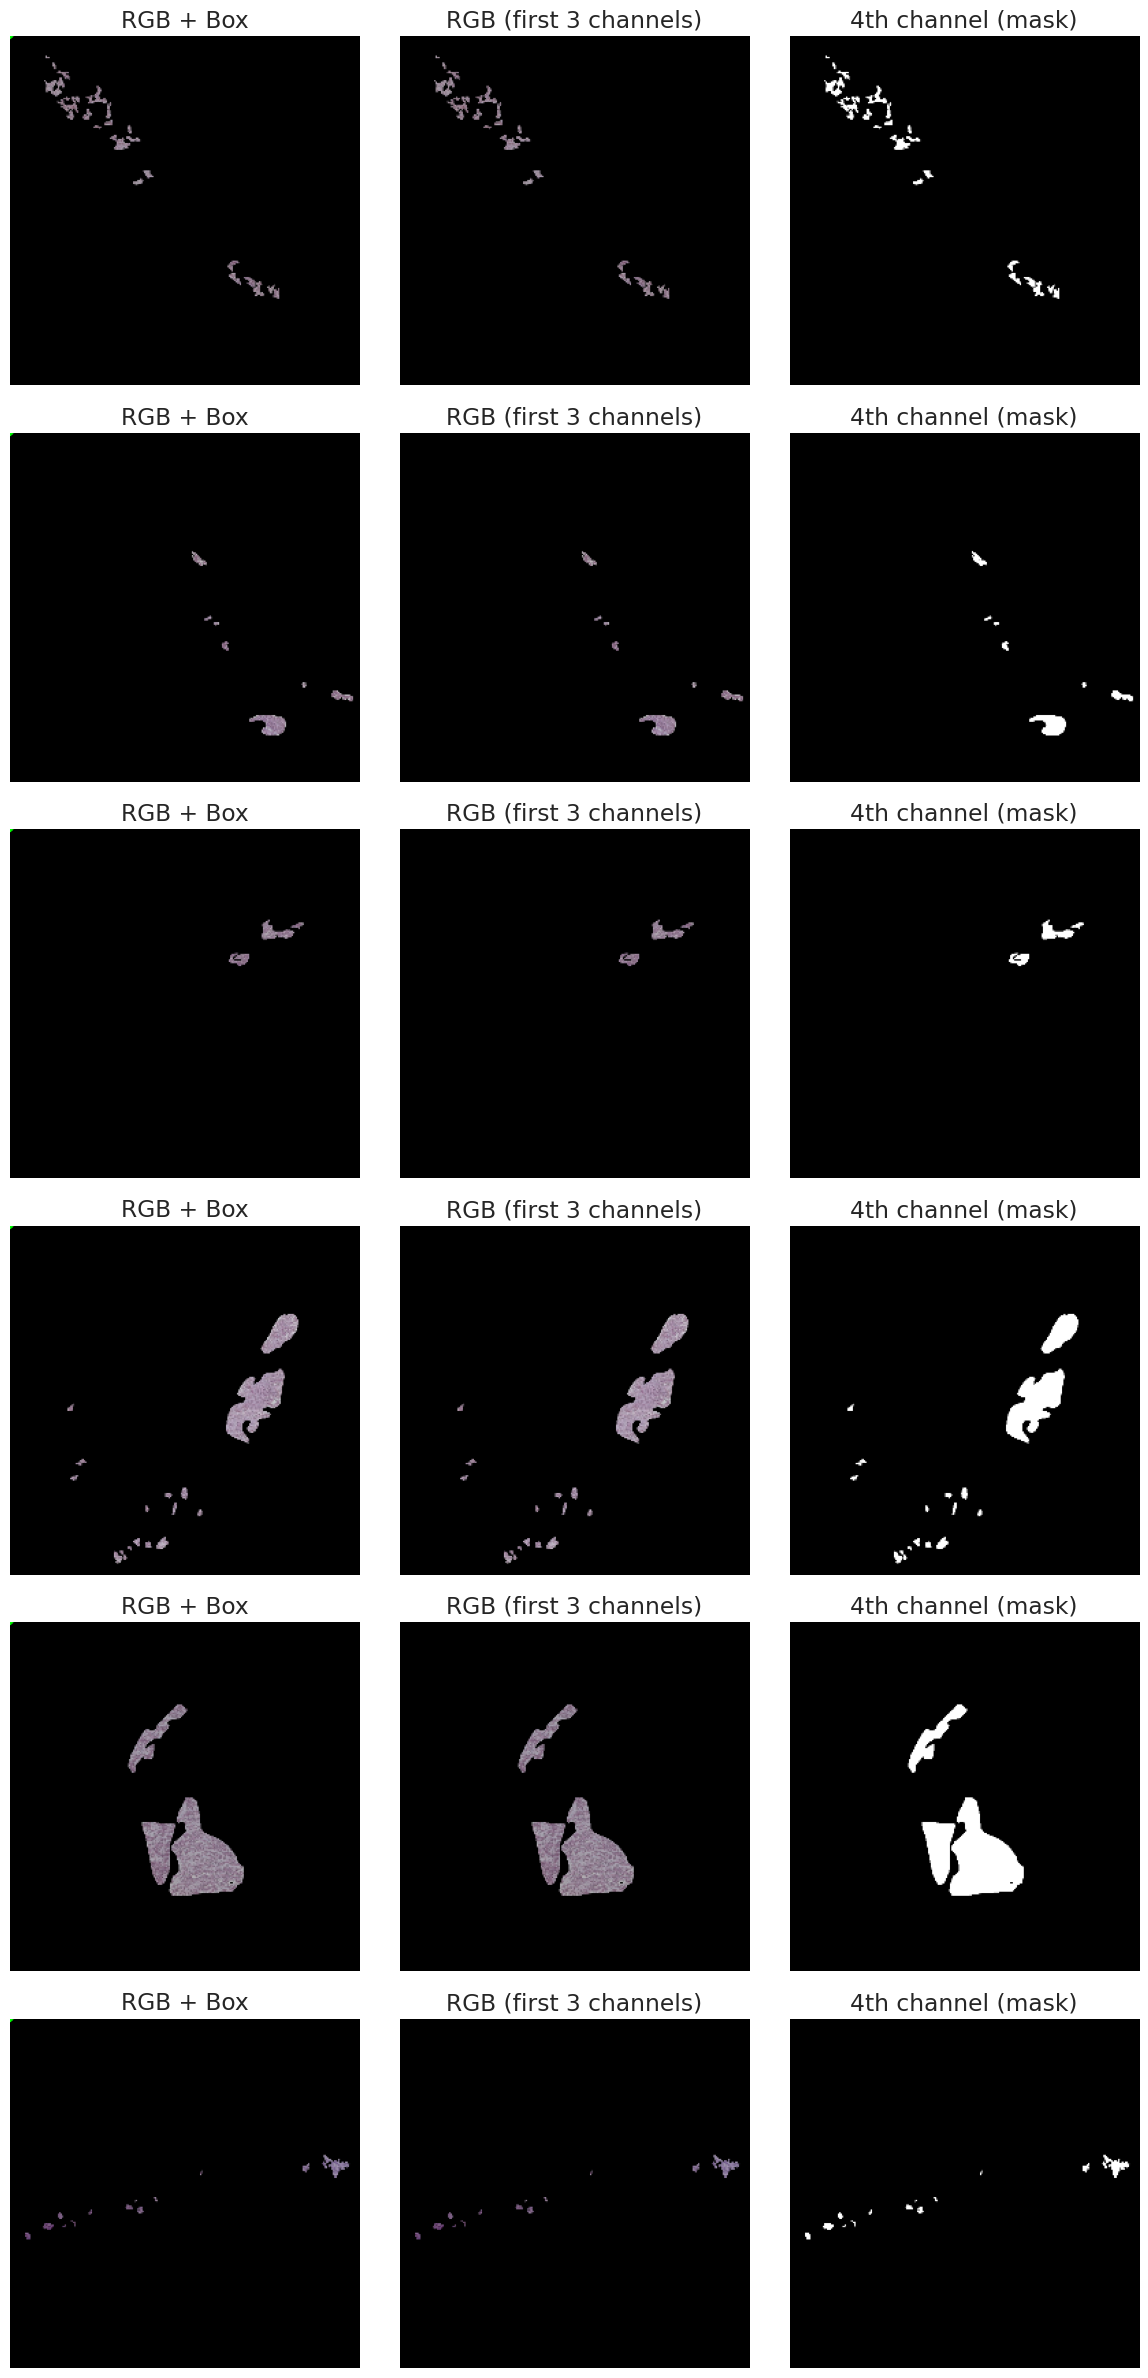

In [110]:
def visualize_test_images_with_boxes(images, box_preds, max_images=6):
    """
    Shows side-by-side:
    - RGB image (first 3 channels)
    - Mask / 4th channel
    And draws bounding boxes on the RGB image.

    Works for (H,W,4) TIFF images.
    """
    n = min(max_images, len(images))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    if n == 1:
        axes = [axes]

    for i in range(n):
        img4 = images[i]            # (H,W,4)
        rgb = img4[:, :, :3]        # first 3 channels
        mask = img4[:, :, 3]        # 4th channel

        h, w, _ = rgb.shape

        # --------- Box prediction ---------
        box = box_preds[i]

        # Auto-detect if box is normalized (0–1)
        if np.any(box > 1.2) or np.any(box < -0.2):
            # Looks like raw coordinates → convert to pixel dims
            x1, y1, x2, y2 = box.astype(int)
        else:
            # Normalized → scale to image size
            x1 = int(box[0] * w)
            y1 = int(box[1] * h)
            x2 = int(box[2] * w)
            y2 = int(box[3] * h)

        rgb_box = rgb.copy()
        cv2.rectangle(rgb_box, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # ============ PLOT ============

        # RGB with box
        axes[i][0].imshow(rgb_box.astype(np.uint8))
        axes[i][0].set_title(f"RGB + Box")
        axes[i][0].axis("off")

        # Raw RGB
        axes[i][1].imshow(rgb.astype(np.uint8))
        axes[i][1].set_title("RGB (first 3 channels)")
        axes[i][1].axis("off")

        # Mask channel
        axes[i][2].imshow(mask, cmap="gray")
        axes[i][2].set_title("4th channel (mask)")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_test_images_with_boxes(X_test_raw, box_preds, max_images=6)


In [111]:
def get_rgb(img4):
    """img4 = H x W x 4"""
    return img4[..., :3]  # only channels 0,1,2

def get_mask(img4):
    return img4[..., 3]


In [112]:
def show_rgb_with_box(img4, box):
    img = get_rgb(img4).copy()
    h, w, _ = img.shape

    # If predicted boxes are NOT normalized ([0,1]) — we must clamp them.
    x1 = int(box[0] * w)
    y1 = int(box[1] * h)
    x2 = int(box[2] * w)
    y2 = int(box[3] * h)

    # Safety fix preventing negative or >image coords
    x1 = max(0, min(x1, w-1))
    y1 = max(0, min(y1, h-1))
    x2 = max(0, min(x2, w-1))
    y2 = max(0, min(y2, h-1))

    cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
    plt.imshow(img)
    plt.axis("off")

def show_rgb_and_heat(img4, alpha=0.45):
    rgb = get_rgb(img4)
    heat = get_mask(img4)

    # Normalize heatmap to [0,1]
    h_norm = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)

    plt.imshow(rgb)
    plt.imshow(h_norm, cmap="jet", alpha=alpha)
    plt.axis("off")


In [113]:
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

path = os.path.join(TEST_IMG_DIR, "image_0000.tiff")
img4 = tiff.imread(path)    # preserves all channels exactly
print("Shape:", img4.shape)


Shape: (1097, 1024, 4)


(-0.5, 1023.5, 1096.5, -0.5)

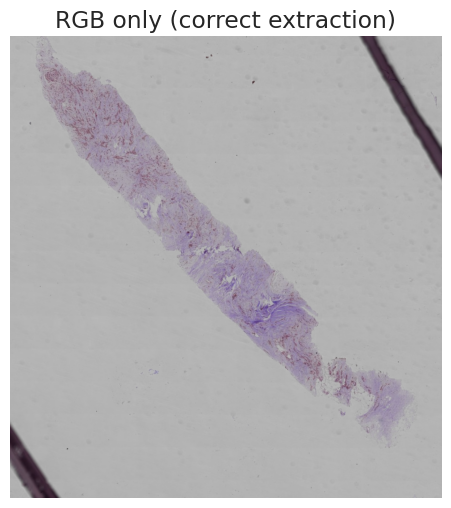

In [114]:
rgb = img4[..., :3]   # take first 3 channels only

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("RGB only (correct extraction)")
plt.axis("off")


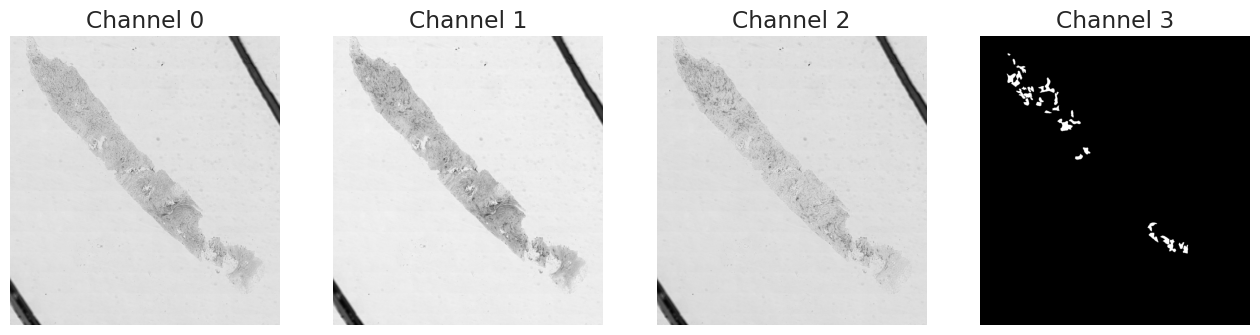

In [115]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))

titles = ["Channel 0", "Channel 1", "Channel 2", "Channel 3"]
for i in range(4):
    ax = axes[i]
    ax.imshow(img4[..., i], cmap="gray")
    ax.set_title(titles[i])
    ax.axis("off")


(-0.5, 1023.5, 1096.5, -0.5)

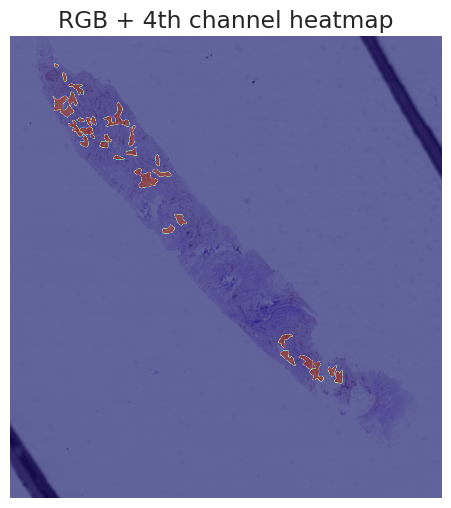

In [116]:
mask = img4[..., 3]
mask_norm = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.imshow(mask_norm, cmap="jet", alpha=0.45)
plt.title("RGB + 4th channel heatmap")
plt.axis("off")


In [133]:
x, _ = train_box_loader.dataset[0]  # pick first sample
print("RGB min/max:", x[:3].min().item(), x[:3].max().item())
print("Mask min/max:", x[3].min().item(), x[3].max().item())


RGB min/max: -1.0203081369400024 1.6116777658462524
Mask min/max: 0.0 255.0


In [118]:
img, _ = train_box_loader.dataset[0]
img = train_box_loader.dataset.normalize_4ch(img)
print("RGB min/max:", img[:3].min().item(), img[:3].max().item())
print("Mask min/max:", img[3].min().item(), img[3].max().item())


RGB min/max: -2.1263132095336914 -1.776354193687439
Mask min/max: 0.0 255.0


In [119]:
#after changing normalize_4ch
img, _ = train_box_loader.dataset[0]
img = train_box_loader.dataset.normalize_4ch(img)
print("RGB min/max:", img[:3].min().item(), img[:3].max().item())
print("Mask min/max:", img[3].min().item(), img[3].max().item())


RGB min/max: -2.1263132095336914 -1.776354193687439
Mask min/max: 0.0 255.0


---

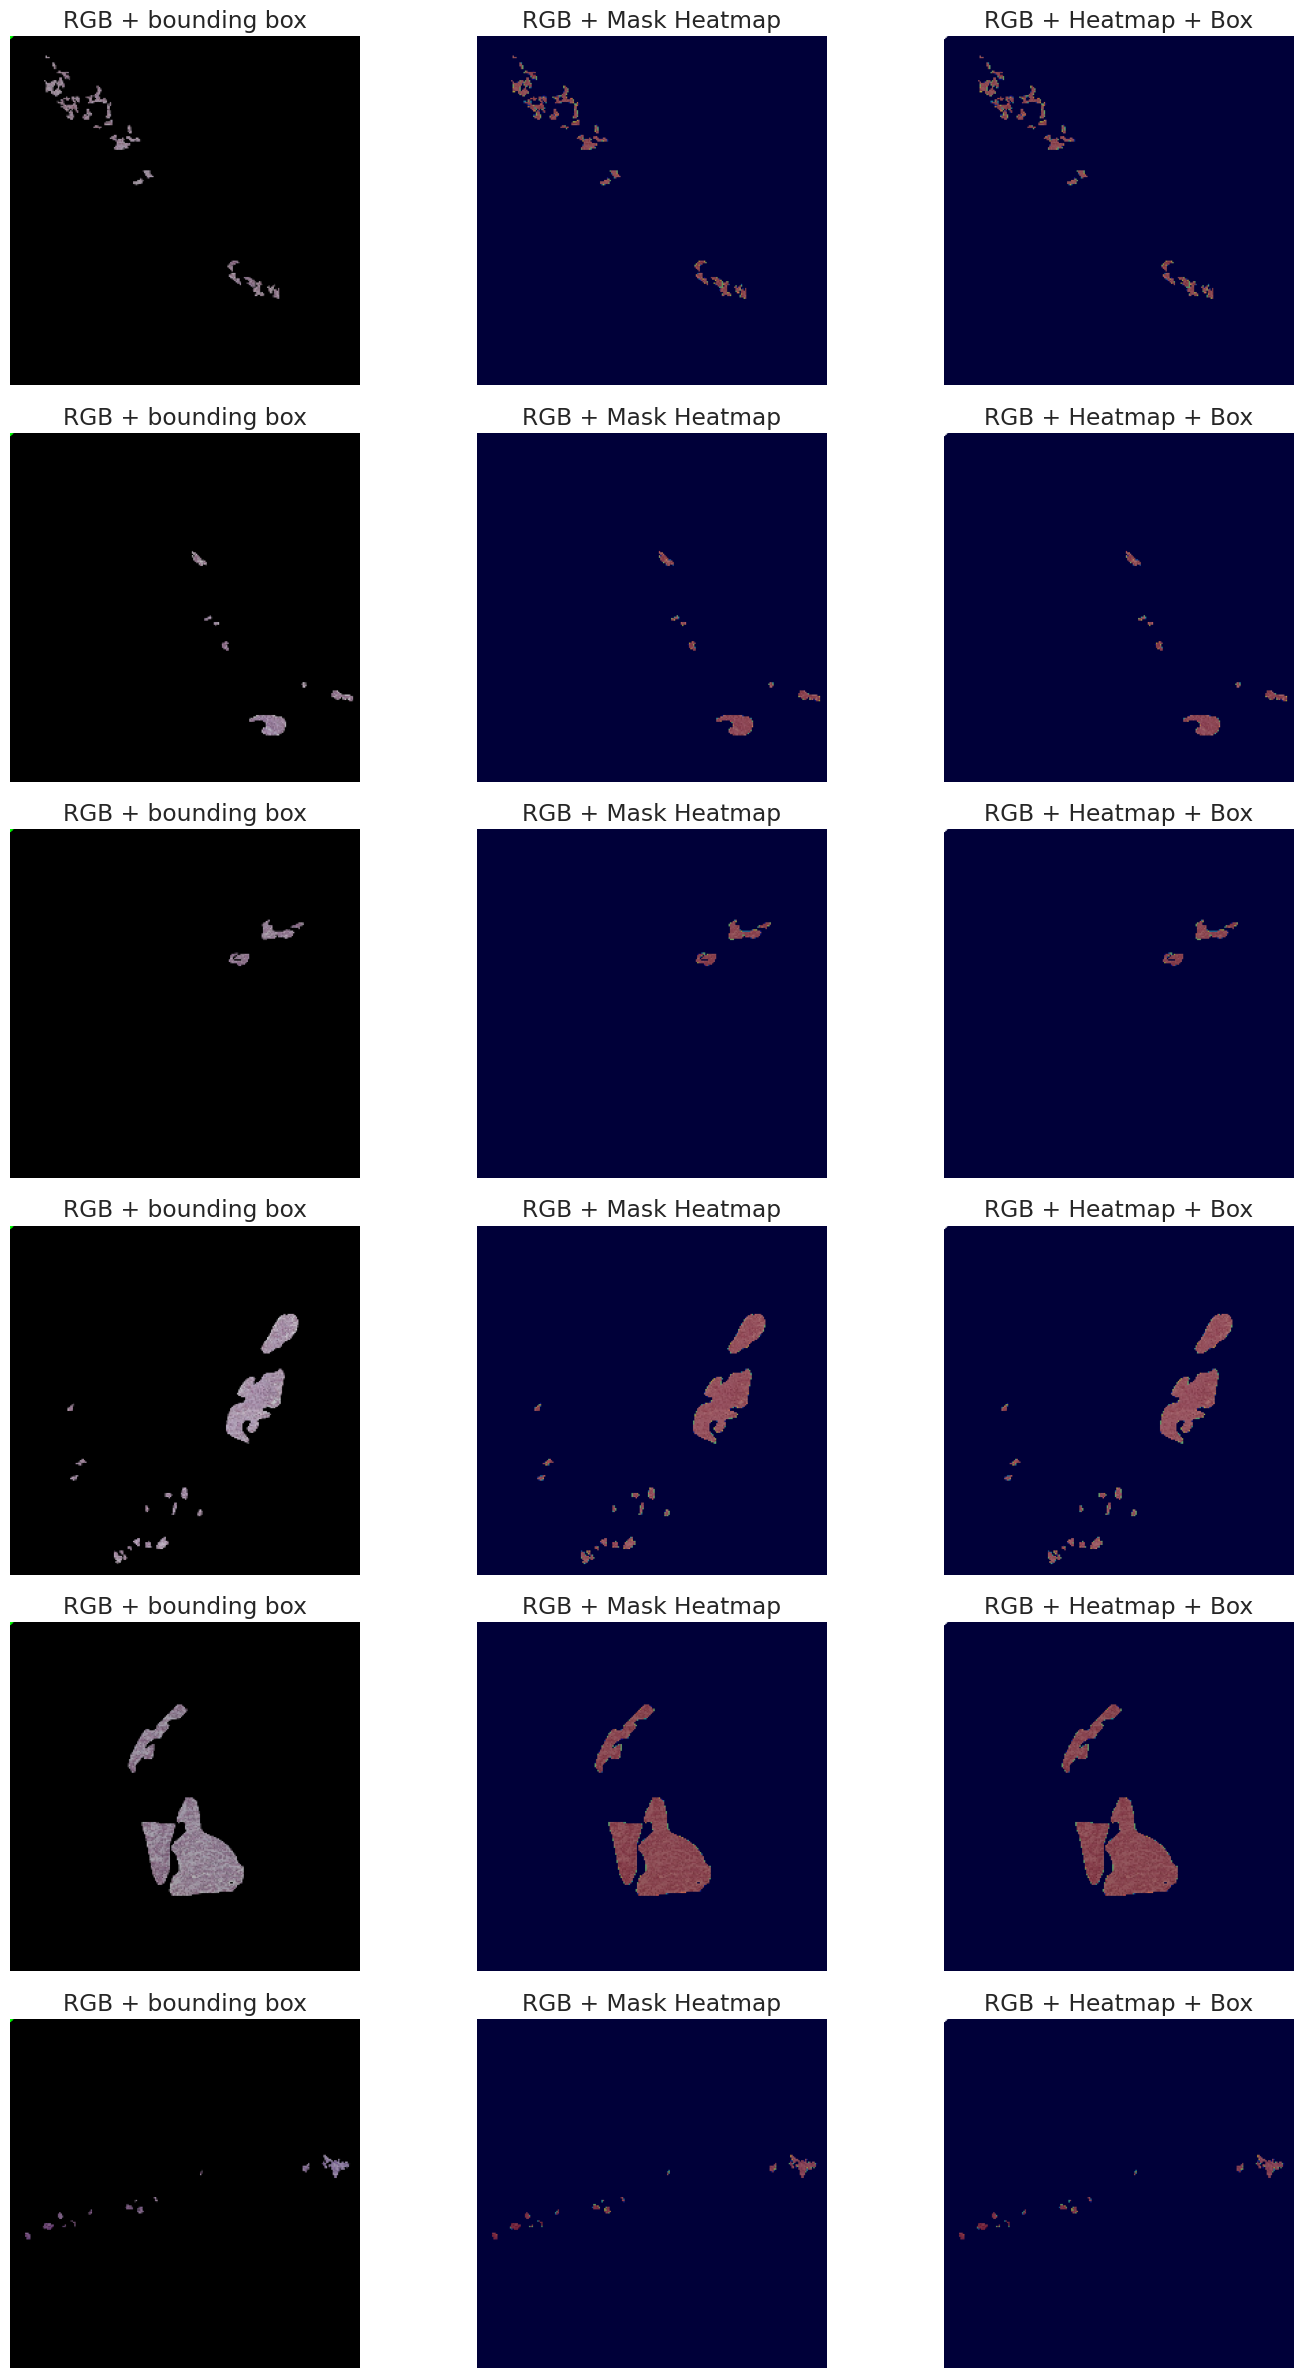

In [120]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def overlay_mask_heatmap(rgb, mask, alpha=0.45, cmap='jet'):
    """
    Convert mask → heatmap and overlay it on RGB image.
    """
    heatmap = plt.get_cmap(cmap)(mask / (mask.max() + 1e-6))[:, :, :3]  # RGB
    heatmap = (heatmap * 255).astype(np.uint8)

    overlay = cv2.addWeighted(rgb, 1 - alpha, heatmap, alpha, 0)
    return overlay


def visualize_test_with_heatmap(images, box_preds, max_images=6):
    n = min(max_images, len(images))
    fig, axes = plt.subplots(n, 3, figsize=(15, 4 * n))

    if n == 1:
        axes = [axes]

    for i in range(n):
        img4 = images[i]                       # (H,W,4)
        rgb  = img4[:, :, :3].astype(np.uint8) # clean RGB
        mask = img4[:, :, 3]                   # mask (float or int)

        h, w, _ = rgb.shape

        # ======= Decode normalized box =======
        bx = box_preds[i]
        x1 = int(np.clip(bx[0], 0, 1) * w)
        y1 = int(np.clip(bx[1], 0, 1) * h)
        x2 = int(np.clip(bx[2], 0, 1) * w)
        y2 = int(np.clip(bx[3], 0, 1) * h)

        # ======= Images =========
        rgb_box = rgb.copy()
        cv2.rectangle(rgb_box, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # heatmap overlay
        heat_overlay = overlay_mask_heatmap(rgb, mask)
        heat_overlay_box = heat_overlay.copy()
        cv2.rectangle(heat_overlay_box, (x1, y1), (x2, y2), (255, 255, 255), 3)

        # ======= Plot =======
        # 1) RGB
        axes[i][0].imshow(rgb_box)
        axes[i][0].set_title("RGB + bounding box")
        axes[i][0].axis("off")

        # 2) Mask heatmap over RGB
        axes[i][1].imshow(heat_overlay)
        axes[i][1].set_title("RGB + Mask Heatmap")
        axes[i][1].axis("off")

        # 3) Heatmap + Box
        axes[i][2].imshow(heat_overlay_box)
        axes[i][2].set_title("RGB + Heatmap + Box")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_test_with_heatmap(X_test_raw, box_preds, max_images=6)


In [142]:
# ============================================================
# Submission generation (classification)
# ============================================================

SUBMISSION_CSV = "YanaTest.csv"

# For submission: work directly from the files in TEST_IMG_DIR.
# Ensure:
# - only img_XXXX.png (ignore masks)
# - all resized to IMG_SIZE
# - same normalization style as training

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),           # fix H,W
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=False),    # match training (0–255)
])

test_files = sorted([
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".tiff", ".png", ".jpg", ".jpeg")) and f.startswith("img_")
])

print("Number of test images used in submission:", len(test_files))

cls_model.eval()
rows = []
BATCH_SIZE_SUB = 64

with torch.no_grad():
    for start in range(0, len(test_files), BATCH_SIZE_SUB):
        end = start + BATCH_SIZE_SUB
        batch_files = test_files[start:end]

        batch_imgs = []
        for fname in batch_files:
            img_path = os.path.join(TEST_IMG_DIR, fname)
            # Load with 4 channels
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

            # Ensure 4 channels
            if img.ndim == 2:  # grayscale
                img = np.stack([img]*3 + [np.zeros_like(img)], axis=-1)
            elif img.shape[2] == 3:  # RGB → append dummy mask
                mask_channel = np.zeros_like(img[:, :, 0])
                img = np.dstack([img, mask_channel])
            elif img.shape[2] >= 4:
                img = img[:, :, :4]  # keep 4 channels

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = transform_test(Image.fromarray(img))
            # normalize RGB only
            img = train_box_loader.dataset.normalize_4ch(img)

            batch_imgs.append(img)

        batch_tensor = torch.stack(batch_imgs).to(device)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = cls_model(batch_tensor)

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        labels_str = label_encoder.inverse_transform(preds)

        for fname, lab in zip(batch_files, labels_str):
            # Replace "image_" with "img_" and convert extension to .png
            base_name = os.path.splitext(fname)[0]       # remove original extension
            sample_name = base_name + ".png"
            
            rows.append({
                "sample_index": sample_name,
                "label": lab,
            })
                    

sub_df = pd.DataFrame(rows)
sub_df.to_csv(SUBMISSION_CSV, index=False)
print("Saved submission to", SUBMISSION_CSV)
print(sub_df.head())
print("Submission shape:", sub_df.shape)

Number of test images used in submission: 954
Saved submission to YanaTest.csv
   sample_index      label
0  img_0000.png  Luminal B
1  img_0001.png    HER2(+)
2  img_0002.png  Luminal B
3  img_0003.png  Luminal B
4  img_0004.png  Luminal B
Submission shape: (954, 2)


In [144]:
from IPython.display import FileLink
FileLink("YanaTest.csv")

/kaggle/working/YanaTest.csv